In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [21]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from langgraph.types import interrupt
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
from typing import List, Literal

In [5]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [4]:
# STATE

class EmailState(BaseModel):
    query:str = ""
    draft:str = ""
    humanfeedback:str = ""
    final_answer:str = ""


In [37]:
# Node
# Query - Draft - HFB - Send - End

def draft_node(state:EmailState) -> EmailState:
    if state.humanfeedback:
        draft = llm.invoke(f"""Rewrite the draft email for subject: {state.query},
                                You have generated this email: {state.draft},
                                Human feedback to apply: {state.humanfeedback}
                                
        """).content
    else:
        draft = llm.invoke(state.query).content
    state.draft = draft
    return state

def human_feedback_node(state:EmailState) -> EmailState:
    feedback = interrupt(
        {
            "draft_email": state.draft,
            "question": "Do you want to continue or rewrite email? "
        }
    )
    fb = (feedback or "").strip().lower()
    if fb in ('yes','ok','approved'):
        state.humanfeedback = ""
        return state
    else:
        state.humanfeedback = feedback
        return state

def final_resp(state:EmailState) -> EmailState:
    if state.humanfeedback:
        state.final_answer = state.humanfeedback
        return state
    else:
        print("Email sent successfully...")
        state.final_answer = "Email sent successfully!!"
        return state

def conditional_routing(state:EmailState) -> Literal["draft_mail","final_resp"]:
    if state.humanfeedback:
        return "draft_mail"
    return "final_resp"
    

In [38]:
graph = StateGraph(EmailState)

graph.add_node("draft_mail",draft_node)
graph.add_node("human_response",human_feedback_node)
graph.add_node("final_resp",final_resp)

graph.add_edge(START, "draft_mail")
graph.add_edge("draft_mail", "human_response")
graph.add_conditional_edges("human_response", conditional_routing)
graph.add_edge("final_resp", END)

graph = graph.compile(checkpointer=InMemorySaver())



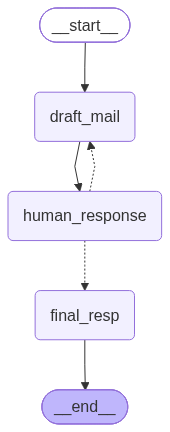

In [39]:
graph

In [40]:
res = graph.invoke({"query":"Send an email for medical leave from first to fifth october 2026,\
               due to an eye infection.So create a simple mail"}, {"configurable":{"thread_id":"2"}})

In [41]:
print(res["draft"])

**Subject:** Medical Leave Request (Oct 1 – Oct 5, 2026)

Dear [Supervisor’s Name],

I hope you are well. I am writing to inform you that I have been diagnosed with an eye infection and, on my doctor’s advice, need to take medical leave to recover fully.

I kindly request leave from **Monday, 1 October 2026 through Friday, 5 October 2026**. I will ensure that any urgent tasks are handed over to a colleague and will be reachable by email for any critical matters, should my condition permit.

Thank you for your understanding and support.

Best regards,

[Your Full Name]  
[Your Position]  
[Your Department]  
[Contact Phone Number]  


In [ ]:
#graph.invoke(Command(resume="No, I dont want to send this email."), {"configurable":{"thread_id":"1"}})

{'query': 'Send an email for medical leave from first to fifth october 2026,               due to an eye infection.So create a simple mail',
 'draft': '**Subject:** Medical Leave Request (Oct\u202f1\u202f–\u202fOct\u202f5,\u202f2026)\n\nDear [Supervisor’s Name],\n\nI am writing to inform you that I have been diagnosed with an eye infection and, on my doctor’s advice, need to take medical leave to recover fully. I kindly request leave from **Monday, 1\u202fOctober\u202f2026, through Friday, 5\u202fOctober\u202f2026**.\n\nI will ensure that any pending tasks are handed over to a colleague and will be reachable via email for any urgent matters. I will also provide a medical certificate upon my return, if required.\n\nThank you for your understanding and support.\n\nBest regards,  \n[Your Full Name]  \n[Your Position]  \n[Your Department]  \n[Contact Phone Number]  ',
 'humanfeedback': 'No, I dont want to send this email.',
 'final_answer': 'No, I dont want to send this email.'}

In [44]:
res = graph.invoke(Command(resume="I want to change the dates,I want to take leave from 4th to 10th"), {"configurable":{"thread_id":"2"}})

In [45]:
print(res["draft"])

**Subject:** Medical Leave Request (4 Oct – 10 Oct 2026)

Dear [Supervisor’s Name],

I hope you are well. I have been diagnosed with an eye infection, and my doctor has advised me to rest until it clears.

I would like to request medical leave from **Monday, 4 October 2026 through Monday, 10 October 2026**. I will ensure that any urgent tasks are handed over to a colleague and will be reachable by email for critical matters, health permitting.

Thank you for your understanding.

Best regards,

[Your Full Name]  
[Your Position]  
[Your Department]  
[Contact Phone Number]  


In [46]:
res = graph.invoke(Command(resume="ok"), {"configurable":{"thread_id":"2"}})

Email sent successfully...


In [47]:
print(res["draft"])

**Subject:** Medical Leave Request (4 Oct – 10 Oct 2026)

Dear [Supervisor’s Name],

I hope you are well. I have been diagnosed with an eye infection, and my doctor has advised me to rest until it clears.

I would like to request medical leave from **Monday, 4 October 2026 through Monday, 10 October 2026**. I will ensure that any urgent tasks are handed over to a colleague and will be reachable by email for critical matters, health permitting.

Thank you for your understanding.

Best regards,

[Your Full Name]  
[Your Position]  
[Your Department]  
[Contact Phone Number]  
